In [1]:
import bw2data, bw2io, bw2calc
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime
import os
import re
import pandas as pd
import numpy as np
import pickle

In [2]:
import sys
sys.path.append('../utils/') 
from elec_builder import *

In [3]:
# activate the bw project
bw2data.projects.set_current("ei311")
#for db in bw2data.databases:
#    print(db, len(bw2data.Database(db)))

In [4]:
bw2data.databases

Databases dictionary with 17 object(s):
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-cutoff
	ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24
	ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22
	ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22
	ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22
	ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22
	ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22
	ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22
	ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22
	ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22
	ei_cutoff_3.11_remind_SSP2-NDC_2030 2025-11-21
	ei_cutoff_3.11_remind_SSP2-NDC_2040 2025-11-21
	ei_cutoff_3.11_remind_SSP2-NDC_2050 2025-11-21
	elec_PV_foreground
	elec_hydro_reservoir_foreground
	elec_wind_foreground

### 1. building wind_foreground 
- China,  nner mongolia: https://pubmed.ncbi.nlm.nih.gov/36123557/ (Fifty-six percent of the potential is located in Inner Mongolia, Xinjiang, and Gansu provinces)
- the U.S. , Texas (US-TRE: Texas Regional Entity) was chose for two reasons1.  it has high elec demand, 2. it has huge wind potential :  https://docs.nrel.gov/docs/fy11osti/51555.pdf 

In [5]:
wind_db = bw2data.Database("elec_wind_foreground")
len(wind_db)

18

In [6]:
act_list = list(wind_db)[2:4]
for act in act_list:
    tech_excs = list(act.technosphere())
    print(len(tech_excs))
    exc = tech_excs[0]
    print(exc)

1
Exchange: 1 kilowatt hour 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, US-TRE, None) to 'market for electricity, wind, high voltage, US-TRE, SSP2-M, 2040' (kWh, US-TRE, None)>
1
Exchange: 1 kilowatt hour 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, US-TRE, None) to 'market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2050' (kWh, US-TRE, None)>


In [7]:
rows = []   # collect results for all acts
act_list = list(wind_db)   
for act in act_list: 
    print(act)

    name = act.get("name")
    name_parts = [p.strip() for p in name.split(",")]
    # run static LCI + premise_GWP vs. pGWP100 first: 
    pgwp_fixedco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - fixed-AGWPCO2")
    pgwp_dpco2 = find_dpGWP100_method(name_parts[-2], int(name_parts[-1]), method_suffix = "pGWP100 - dp-AGWPCO2")
    gwp =  ('ecoinvent-3.11', 'IPCC 2021 (incl. biogenic CO2)', 'climate change: total (incl. biogenic CO2, incl. SLCFs)', 'global warming potential (GWP100)')   

    lca_gwp = bw2calc.lca.LCA({act: 1}, method=gwp)
    lca_gwp.lci(); lca_gwp.lcia()
    score_gwp = float(lca_gwp.score)

    lca_fixed = bw2calc.lca.LCA({act: 1}, method=pgwp_fixedco2)
    lca_fixed.lci(); lca_fixed.lcia()
    score_fixedco2 = float(lca_fixed.score)

    lca_dp = bw2calc.lca.LCA({act: 1}, method=pgwp_dpco2)
    lca_dp.lci(); lca_dp.lcia()
    score_dpco2 = float(lca_dp.score)

    print(score_gwp, score_fixedco2, score_dpco2) 

    # ---- store results for this activity ----
    rows.append({
        "Activity": name,                      # index value later
        "gwp100": score_gwp,
        "pGWP100_fixedCO2": score_fixedco2,
        "pGWP100_dpCO2": score_dpco2,
    })


'market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050' (kWh, CN-NM, None)
0.017832839443927488 0.017479730833468446 0.017767653715312734
'market for electricity, wind, high voltage, CN-NM, SSP2-M, 2030' (kWh, CN-NM, None)
0.03772456450870744 0.04333770609647508 0.03729870466003862
'market for electricity, wind, high voltage, US-TRE, SSP2-M, 2040' (kWh, US-TRE, None)
0.01903853817398698 0.020857996513184335 0.018874909198042904
'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2030' (kWh, CN-NM, None)
0.03873485503955145 0.051867216422872855 0.037741120282590676
'market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2030' (kWh, CN-NM, None)
0.036905774496070416 0.037424055482719876 0.03670104390938097
'market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2040' (kWh, CN-NM, None)
0.023273288197598805 0.02304142307471048 0.023191330361879238
'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2040' (kWh, CN-NM, None)
0.036707947674406785 0.

In [8]:
df_scores = pd.DataFrame(rows)
df_scores = df_scores.set_index("Activity")

df2 = df_scores.sort_values(by=['Activity'])
df2 

,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2
Activity,,,
"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2030",0.036906,0.037424,0.036701
"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2040",0.023273,0.023041,0.023191
"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050",0.017833,0.017480,0.017768
"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2030",0.037725,0.043338,0.037299
"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2040",0.034046,0.037299,0.033753
"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2050",0.031186,0.032591,0.030982
"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2030",0.038735,0.051867,0.037741
"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2040",0.036708,0.047138,0.035866
"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050",0.034396,0.041592,0.033688


### see the results from old "without prospective decay" side: "..dynLCI/"
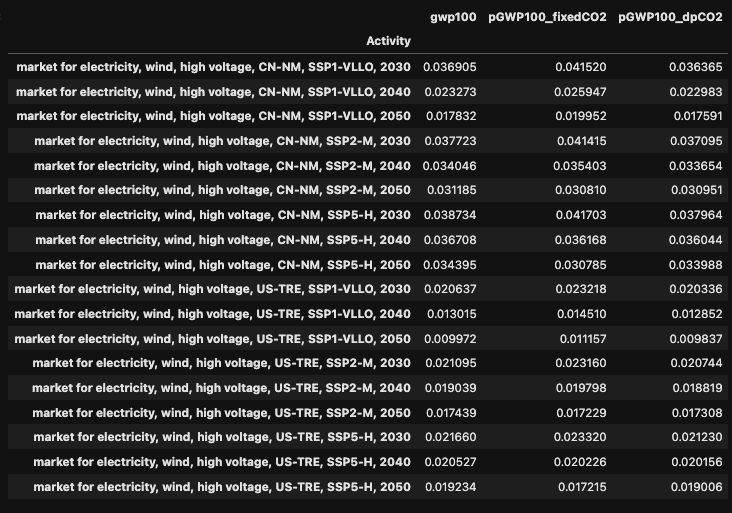

In [9]:
df2.to_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")

### 2. building dpLCI

In [10]:
find_dpGWP100_method('SSP1-VLLO', 2050, method_suffix = "pGWP100 - dp-AGWPCO2")

('Climate Change prospective GWP100',
 'SSP119',
 'MY2050',
 'pGWP100 - dp-AGWPCO2')

In [11]:
database_dates = {
    'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22': datetime.strptime("2050", "%Y"),

    'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22': datetime.strptime("2030", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22': datetime.strptime("2040", "%Y"),
    'ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22': datetime.strptime("2050", "%Y"),
    
    "elec_wind_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

In [12]:
len(list(wind_db))

18

In [13]:
wind_db_203050 = [
    act for act in wind_db 
    if "2050" in str(act.get('name', '')) or  "2030" in str(act.get('name', ''))
]
len(list(wind_db_203050))

12

In [14]:
dp_results = {}

for act in list(wind_db_203050): 
    print(act)
 
    #### dynamic LCI:: 
    assign_td_from_foreground_db( 
        select_act = act,
        elec_td_year=10,
        resolution="Y",
        kind="uniform",
        fg_db_name="elec_wind_foreground",
        verbose = True
     )

    tlca = run_dp_timex_lca(foreground_act = act ,   
                    pathway = None,
                    year = None,
                    method = None,
                    database_dates = database_dates, #None not working, has to incl. all 9 background DB ... 
                    temporal_grouping="year", 
                    method_prefix = "Climate Change prospective GWP100",
                    method_suffix = "pGWP100 - fixed-AGWPCO2", 
                    fg_db_name = 'elec_wind_foreground'
     )

    tlca.lci()
    tlca.dynamic_inventory.shape

    # dyn-foreground LCI + static background LCI + pGWP100
    lca_0 = tlca.base_score 
    print(lca_0)
    
    # dpLCI (dyn-foreground LCI + dyn background LCI) +  pGWP100
    tlca.static_lcia()
    lca_1 = tlca.static_score
    print(lca_1)

    act_name = act.get("name")
    dp_results[act_name] = {
        "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": float(lca_0),   # static BG LCI + dyn FG LCI
        "full dp-LCI, pGWP100-fixedCO2": float(lca_1),      # dyn BG LCI + dyn FG LCI
    }

    
    #### now save all dyLCI flows to pandas 
    df = tlca.dynamic_inventory_df

    ##### important to convert flow and act as str to excel 
    df["flow"] = df["flow"].astype(str)
    df["activity"] = df["activity"].astype(str)

    ### export df to dp-LCI_output folder, using the act name as the excel name 
    out_dir = "dp-LCI_output/wind_dpLCI"
    os.makedirs(out_dir, exist_ok=True)    
    raw_name = act["name"]
    safe_name = re.sub(r"[^A-Za-z0-9_\-()]+", "_", raw_name)   # replace spaces/special chars
    
    excel_path = os.path.join(out_dir, f"{safe_name}.xlsx")
    
    df.to_excel(excel_path, index=False)    
    print(f"✔ Exported dynamic inventory DF for '{raw_name}' → {excel_path}")





import pickle

out_dir = "dp-LCI_output/wind_dpLCI"
os.makedirs(out_dir, exist_ok=True)

pickle_path = os.path.join(out_dir, "wind_dp_results_MY2030_2050.pkl")

with open(pickle_path, "wb") as f:
    pickle.dump(dp_results, f)

print(f"✔ Saved dp_results dictionary → {pickle_path}")

2026-03-30 12:37:27.154 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2026-03-30 12:37:27.168 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050' (kWh, CN-NM, None)
TD applied to 'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050' → Exchange: 1 kilowatt hour 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, CN-NM, None) to 'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050' (kWh, CN-NM, None)>
for the activity 'market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050' (kWh, CN-NM, None),it's under SSP-SSP5-H, year-2050 
 we'll use LCIA ('Climate Change prospective GWP100', 'SSP585', 'MY2050', 'pGWP100 - fixed-AGWPCO2')  with background database.datetime = {'ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22': datetime.datetime(2040, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22': datetime.datetime(2050, 1, 1, 0, 0), 'ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22': datetime.datetime(2030, 1, 1, 0, 0), 'ei_cutoff_3.11

2026-03-30 12:40:37.653 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2026-03-30 12:41:47.462 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2026-03-30 12:42:02.184 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2026-03-30 12:42:05.739 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...


Starting graph traversal


2026-03-30 12:42:07.759 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...


...

Starting graph traversal


2026-03-30 14:50:06.007 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...


Calculation count: 1


2026-03-30 14:50:06.175 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2026-03-30 14:50:06.177 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2026-03-30 14:50:06.177 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2026-03-30 14:50:06.179 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2028-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2026-03-30 14:50:06.181 | INFO     | bw_time

0.04333770609647508
0.04406459567034852
✔ Exported dynamic inventory DF for 'market for electricity, wind, high voltage, CN-NM, SSP2-M, 2030' → dp-LCI_output/wind_dpLCI/market_for_electricity_wind_high_voltage_CN-NM_SSP2-M_2030.xlsx
✔ Saved dp_results dictionary → dp-LCI_output/wind_dpLCI/wind_dp_results_MY2030_2050.pkl
